# 선문대학교 컴퓨터공학부
# 2022243101 최완우

### **심부터 데이터셋 불러온 다음 내용 확인하기**

#### **데이터 분석 라이브러리와 csv 파일 불러오기**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

heart = pd.read_csv("5.3.2.heart.csv")

#### **데이터 내용 확인**

In [2]:
list(heart.columns)

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'HeartDisease']

In [3]:
heart.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,HeartDisease
0,40,M,ATA,140.0,289,NaN,Normal,172,N,0.0
1,49,F,NAP,160.0,180,NaN,Normal,156,N,NaN
2,37,M,ATA,NaN,283,NaN,ST,98,N,NaN


In [4]:
heart.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       891 non-null    float64
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       827 non-null    float64
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   HeartDisease    916 non-null    float64
dtypes: float64(3), int64(3), str(4)
memory usage: 71.8 KB


## **심부전 데이터셋 필터링하기**

#### **논리형 인덱싱으로 데이터 필터링하기**

In [5]:
heart['HeartDisease'].head()

0    0.0
1    NaN
2    NaN
3    1.0
4    0.0
Name: HeartDisease, dtype: float64

In [6]:
heart['HeartDisease'] == 1

0      False
1      False
2      False
3       True
4      False
       ...  
913     True
914     True
915     True
916     True
917    False
Name: HeartDisease, Length: 918, dtype: bool

In [7]:
H = heart[heart['HeartDisease'] == 1]
H.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,HeartDisease
3,48,F,ASY,NaN,214,NaN,Normal,108,Y,1.0
8,37,M,ASY,NaN,207,NaN,Normal,130,Y,1.0
11,58,M,ATA,136.0,164,NaN,ST,99,Y,1.0
13,49,M,ASY,140.0,234,NaN,Normal,140,Y,1.0
16,38,M,ASY,110.0,196,NaN,Normal,166,N,1.0


## **07.4 심부전 데이터셋 결측치 처리하기**

#### **for문으로 결측치 비율 확인하기**

In [8]:
heart.isna().mean()

Age               0.000000
Sex               0.000000
ChestPainType     0.000000
RestingBP         0.029412
Cholesterol       0.000000
FastingBS         0.099129
RestingECG        0.000000
MaxHR             0.000000
ExerciseAngina    0.000000
HeartDisease      0.002179
dtype: float64

#### **결측치 비율에 따른 처리 방법**

### **결측치 처리하기**

#### **fillna() 함수로 결측치를 다른 값으로 대체하기**

In [9]:
heart['FastingBS'].value_counts()

FastingBS
0.0    619
1.0    208
Name: count, dtype: int64

In [10]:
heart['FastingBS'] = heart['FastingBS'].fillna(0)

#### **replace() 함수로 결측치를 다른 값으로 대체하기**

In [11]:
heart['RestingBP'] = heart['RestingBP'].fillna(heart['RestingBP'].median())

#### **dropna()로 결측치를 가진 행 제거하기**

In [12]:
heart.dropna(axis = 0, inplace = True)

### **결측치 처리 후에 결측치 개수 다시 확인하기**

In [13]:
heart.info()

<class 'pandas.DataFrame'>
Index: 916 entries, 0 to 917
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             916 non-null    int64  
 1   Sex             916 non-null    str    
 2   ChestPainType   916 non-null    str    
 3   RestingBP       916 non-null    float64
 4   Cholesterol     916 non-null    int64  
 5   FastingBS       916 non-null    float64
 6   RestingECG      916 non-null    str    
 7   MaxHR           916 non-null    int64  
 8   ExerciseAngina  916 non-null    str    
 9   HeartDisease    916 non-null    float64
dtypes: float64(3), int64(3), str(4)
memory usage: 78.7 KB


## **심부전 데이터셋 통계 처리하기**

#### **평균값과 중앙값 구하기**

In [14]:
print(heart["MaxHR"].mean())
print(heart['MaxHR'].median())

136.83078602620088
138.0


#### **열의 빈도수 구하기**

In [15]:
heart['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    202
ATA    172
TA      46
Name: count, dtype: int64

#### **통계량 요약하기**

In [16]:
heart[['Age', 'MaxHR', 'Cholesterol']].describe()

,Age,MaxHR,Cholesterol
count,916.000000,916.000000,916.000000
mean,53.533843,136.830786,198.728166
std,9.425923,25.447917,109.466452
min,28.000000,60.000000,0.000000
25%,47.000000,120.000000,173.000000
50%,54.000000,138.000000,223.000000
75%,60.000000,156.000000,267.000000
max,77.000000,202.000000,603.000000


## **그룹별 집계하기**

In [17]:
heart.groupby(['HeartDisease', 'ChestPainType'])[['Age', 'MaxHR', 'Cholesterol']].mean()

Age       MaxHR  Cholesterol
HeartDisease ChestPainType                                    
0.0          ASY            52.317308  138.548077   226.865385
             ATA            48.236486  152.621622   232.668919
             NAP            51.045802  150.641221   221.503817
             TA             54.692308  150.500000   222.730769
1.0          ASY            55.660714  125.806122   175.974490
             ATA            55.958333  137.500000   233.291667
             NAP            57.549296  129.394366   153.281690
             TA             55.000000  144.500000   186.700000

In [18]:
heart.groupby('Sex')['RestingBP'].mean()

Sex
F    132.119792
M    132.421271
Name: RestingBP, dtype: float64

## **심부전 데이터셋 시각화하기**

#### **심부전 색상 시각화하기**

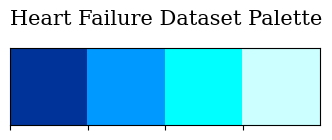

In [19]:
sns.palplot(['#003399', '#0099FF', '#00FFFF','#CCFFFF'])

plt.title('Heart Failure Dataset Palette', loc = 'left', fontfamily = 'serif', fontsize = 15, y = 1.2)
plt.show()

In [20]:
ratio = heart['ChestPainType'].value_counts()
print(ratio)

ChestPainType
ASY    496
NAP    202
ATA    172
TA      46
Name: count, dtype: int64


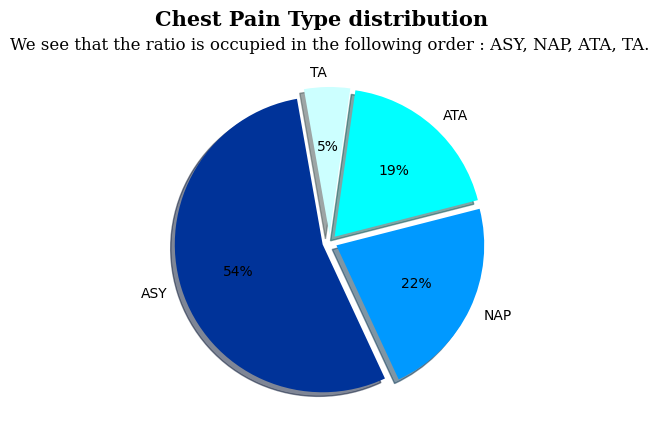

In [21]:
plt.pie(x = ratio, labels = ratio.index,
        autopct = '%0.f%%', startangle = 100,
        explode = [0.05, 0.05, 0.05, 0.05], shadow = True,
        colors = ['#003399', '#0099FF', '#00FFFF','#CCFFFF'])

plt.suptitle('Chest Pain Type distribution', fontfamily = 'serif', fontsize = 15, fontweight = 'bold')
plt.title('We see that the ratio is occupied in the following order : ASY, NAP, ATA, TA.', fontfamily = 'serif', fontsize = 12)

plt.show()

## **심부전 빈도 그래프 그리기**

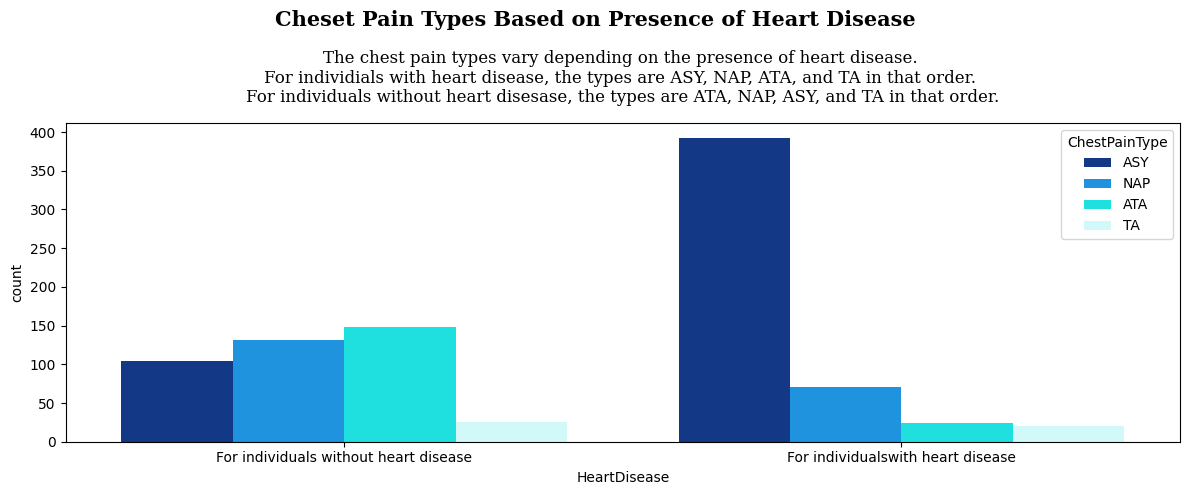

In [22]:
plt.figure(figsize = (12, 5))

sns.countplot(data = heart, x = 'HeartDisease', hue = 'ChestPainType',
              hue_order = ['ASY', 'NAP', 'ATA', 'TA'],
              palette = ['#003399', '#0099FF', '#00FFFF','#CCFFFF'])

plt.suptitle('Cheset Pain Types Based on Presence of Heart Disease', fontfamily = 'serif', fontsize = 15, fontweight = 'bold')
plt.title('The chest pain types vary depending on the presence of heart disease. \nFor individials with heart disease, the types are ASY, NAP, ATA, and TA in that order. \nFor individuals without heart disesase, the types are ATA, NAP, ASY, and TA in that order.',
          fontfamily = 'serif', fontsize = 12, pad = 15)

plt.xticks([0, 1], ['For individuals without heart disease', "For individualswith heart disease"])

plt.tight_layout()
plt.show()

#### **심부전 데이터 영역 그래프 그리기**

In [23]:
Heart_Age = heart.groupby('Age')['HeartDisease'].value_counts().unstack(level = 'HeartDisease')
Heart_Age.head()

HeartDisease,0.0,1.0
Age,,
28,1.0,NaN
29,3.0,NaN
30,1.0,NaN
31,1.0,1.0
32,3.0,2.0


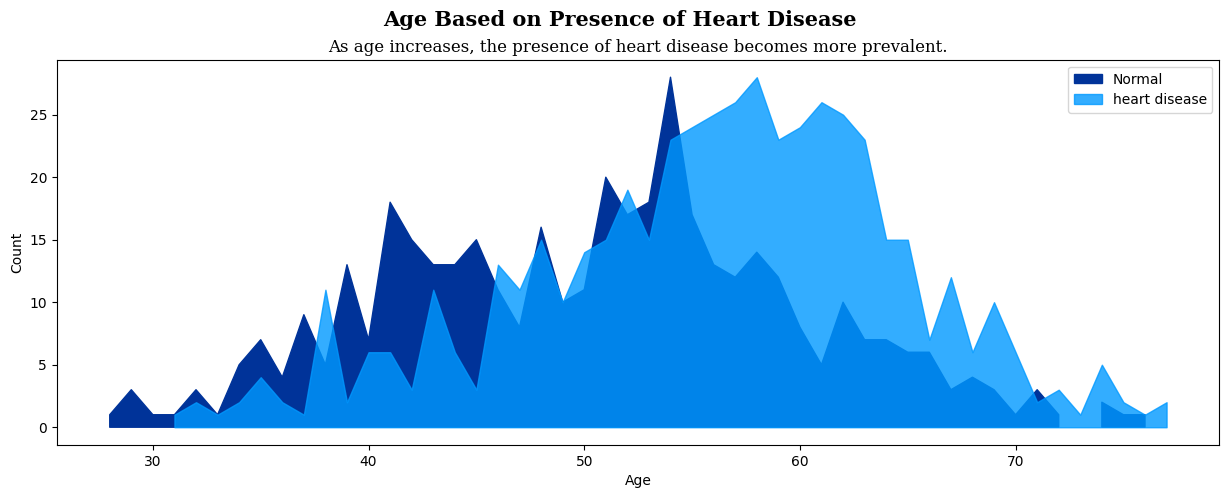

In [24]:
plt.figure(figsize = (15, 5))

plt.fill_between(x = Heart_Age[0].index, y1 = 0, y2 = Heart_Age[0],
                 color = '#003399', alpha = 1, label = 'Normal')
plt.fill_between(x = Heart_Age[1].index, y1 = 0, y2 = Heart_Age[1],
                 color = '#0099FF', alpha = 0.8, label = 'heart disease')

plt.legend()

plt.xlabel('Age')
plt.ylabel('Count')

plt.suptitle('Age Based on Presence of Heart Disease', fontfamily = 'serif', fontsize = 15, fontweight = 'bold')
plt.title('As age increases, the presence of heart disease becomes more prevalent.', fontfamily = 'serif', fontsize = 12)
plt.show()

#### **심부전 범주형 산점도 그래프 그리기**

In [25]:
H_0 = heart[heart['HeartDisease'] == 0]
H_1 = heart[heart['HeartDisease'] == 1]

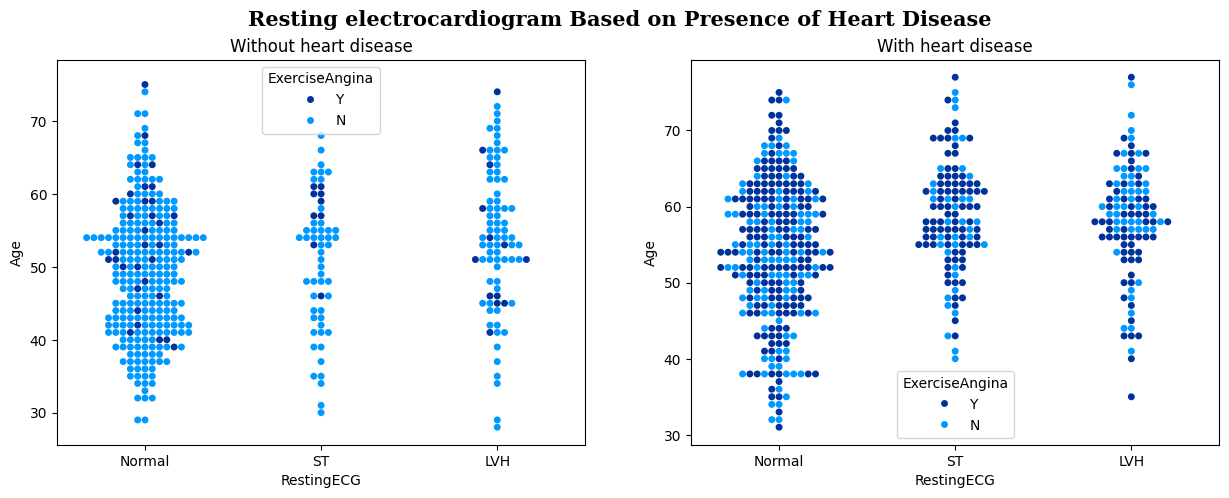

In [26]:
fig = plt.figure(figsize = (15, 5))
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

sns.swarmplot(x = 'RestingECG', y = 'Age', data = H_0, ax = ax1, hue='ExerciseAngina',
              palette = ['#003399', '#0099FF'], hue_order = ['Y', 'N'])

sns.swarmplot(x = 'RestingECG', y = 'Age', data = H_1, ax = ax2, hue = 'ExerciseAngina',
              palette = ['#003399', '#0099FF'], hue_order = ['Y', 'N'])

plt.suptitle('Resting electrocardiogram Based on Presence of Heart Disease', fontfamily = 'serif', fontsize = 15, fontweight = 'bold')
ax1.set_title('Without heart disease')
ax2.set_title('With heart disease')
plt.show()

#### **심부전 워드 클라우드 그리기**

#### **Pubmed 사이트의 심부전관련 논문의 제목 데이터**

In [27]:
pubmed_title = pd.read_csv('pubmed_title.csv')

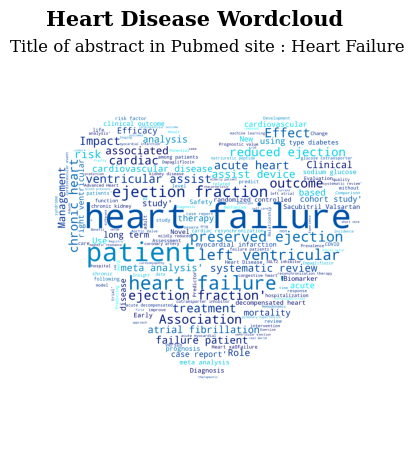

In [32]:
from wordcloud import WordCloud
from PIL import Image

plt.figure(figsize = (10, 5))

text = str(list(pubmed_title['Title']))
mask = np.array(Image.open('image.jpg'))
cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list("", ['#000066','#003399', '#00FFFF'])

wordcloud = WordCloud(background_color = 'white', width = 2500,  height = 1400,
                      max_words = 170, mask = mask, colormap=cmap).generate(text)

plt.imshow(wordcloud)
plt.axis('off')

plt.suptitle('Heart Disease Wordcloud', fontweight = 'bold', fontfamily = 'serif', fontsize = 15)
plt.title('Title of abstract in Pubmed site : Heart Failure', fontfamily = 'serif', fontsize = 12)
plt.show()